In [1]:
import warnings
warnings.filterwarnings("ignore")
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology
from typing import Dict, List, Tuple
import networkx as nx
import matplotlib.pyplot as plt

#### Compare With McOpt

In [2]:
def constrcut_mcopt(beta: float=1.0, method="paris"):
    method, coupling, museed, pflux, rho = method, "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt(method, coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt)
    mcopt.ot_setup()
    return mcopt

In [3]:
def compare_mcopt_admk(beta: float=1.0, method="paris"):
    mcopt = constrcut_mcopt(beta=beta, method=method)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk = test_main(topo.copy(), weights, len(forcing_), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)
    return mcopt.g, forcing_

* graph topology construction
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0010 max(res)=7.4e-09 max(pres)=6.4e-12
   -2.00e+00<=UPDATE<=-2.00e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=1 var=1.11e+00
   -1.80e+00<=UPDATE<=-1.80e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=2 var=1.11e+00
   -1.62e+00<=UPDATE<=-1.62e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=3 var=1.11e+00
   -1.46e+00<=UPDATE<=-1.46e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=4 var=1.11e+00
   -1.31e+00<=UPDATE<=-1.31e+00, deltat=1.00e-01
ierr=0 avg_it=0009 max(res)=7.6e-09 max(pres)=6.8e-12
it=5 var=1.11e+00
   -1.18e+00<=U

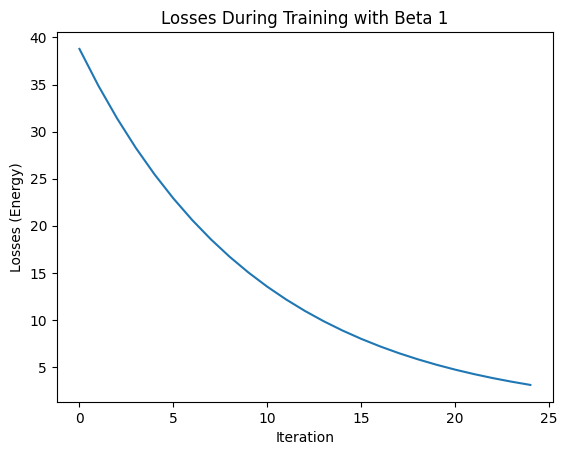

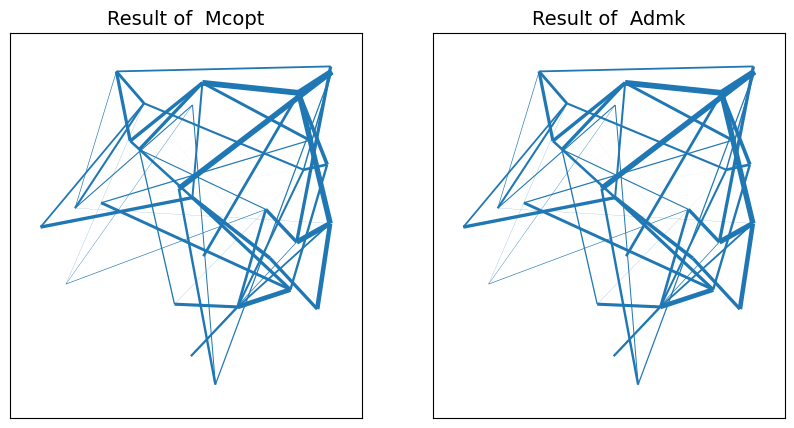

In [4]:
graph, forcing = compare_mcopt_admk(1, "synth")

###### Apply Fine-Grain Method On Waxman Graph

In [5]:
def discretize(graph: nx.Graph, forcing: List[np.ndarray], mesh_size=30, beta=1, max_iter=20):
    num_commodity = len(graph.nodes)
    def grid_coord_idx(coord: Tuple[int, int]): 
        return coord[0] * mesh_size + coord[1]
    
    mesh = nx.grid_2d_graph(mesh_size, mesh_size)
    forcing_grid = [np.zeros(num_commodity) for _ in range(mesh_size * mesh_size)]
    for node in graph.nodes:
        cur_pos_on_grid: Tuple[int, int] = (round(graph.nodes[node]["pos"][0] * mesh_size), round(graph.nodes[node]["pos"][1] * mesh_size))
        cur_pos_idx = grid_coord_idx(cur_pos_on_grid)
        for comm in range(num_commodity):
            forcing_grid[cur_pos_idx][comm] += forcing[node][comm] * 1e5
    for node in mesh.nodes():
        mesh.nodes[node]["amplitude"] = np.linalg.norm(forcing_grid[grid_coord_idx(node)])
    edge_lists = np.array([list((grid_coord_idx(e[0]), grid_coord_idx(e[1]))) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:,0])
    potentials, conductivity_admk = test_main(edge_lists, weights, len(forcing_grid), forcing_grid, beta=beta, max_iter=max_iter)
    return mesh, conductivity_admk    

init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0024 max(res)=9.7e-09 max(pres)=9.6e-07
   -1.94e+00<=UPDATE<=5.36e+02, deltat=7.47e-03
ierr=0 avg_it=0023 max(res)=9.9e-09 max(pres)=8.4e-07
it=1 var=2.46e+01
   -1.93e+00<=UPDATE<=2.29e+02, deltat=7.22e-02
ierr=0 avg_it=0025 max(res)=9.8e-09 max(pres)=8.8e-07
it=2 var=7.72e+00
   -1.80e+00<=UPDATE<=5.60e+01, deltat=1.00e-01
ierr=0 avg_it=0024 max(res)=9.8e-09 max(pres)=9.6e-07
it=3 var=2.04e+00
   -1.62e+00<=UPDATE<=3.95e+01, deltat=1.00e-01
ierr=0 avg_it=0023 max(res)=9.9e-09 max(pres)=1.3e-06
it=4 var=1.20e+00
   -1.45e+00<=UPDATE<=3.01e+01, deltat=1.00e-01
ierr=0 avg_it=0023 max(res)=1.0e-08 max(pres)=1.2e-06
it=5 var=8.27e-01
   -1.30e+00<=UPDATE<=2.38e+01, deltat=1.00e-01
ierr=0 avg_it=0023 max(res)=9.9e-09 max(pres)=1.2e-06
it=6 var=6.15e-01
   -1.17e+00<=

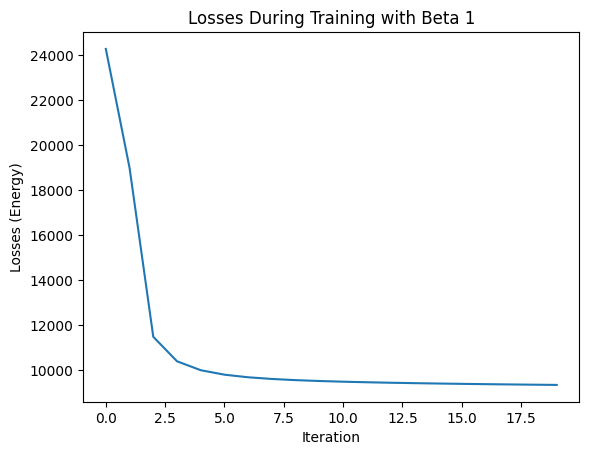

In [6]:
mesh, conductivity_admk = discretize(graph, forcing)

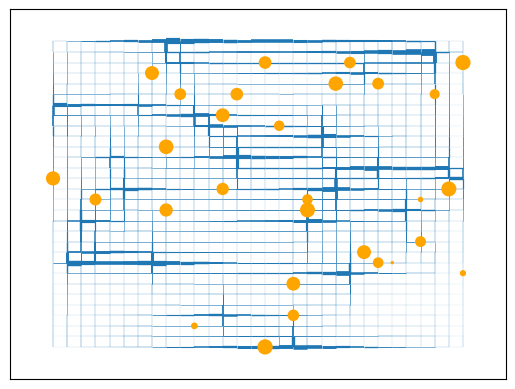

In [7]:
plt.show()
pos = {n: (n[1], n[0]) for n in mesh.nodes()}
nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.1,  edge_color='C0', style='solid')
amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
plt.show()